In [75]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

In [76]:
train_df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test_df  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')

train_df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

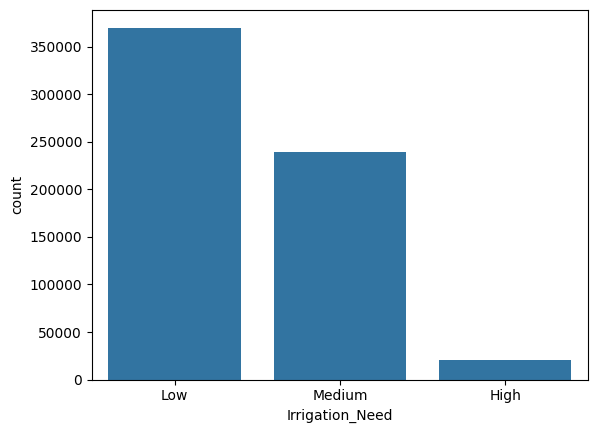

In [77]:
print(train_df.info())
print(train_df.describe())

# Visualisasi distribusi target
sns.countplot(x='Irrigation_Need', data=train_df)
plt.show()

In [78]:
X = train_df.drop(columns=['id', 'Irrigation_Need'])
y = train_df['Irrigation_Need']
X_test = test_df.drop(columns=['id'])

# Encode kategori
cat_cols = X.select_dtypes(exclude='number').columns
for col in cat_cols:
    X[col] = X[col].astype('category').cat.codes
    X_test[col] = X_test[col].astype('category').cat.codes

# Impute & Scale
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_proc = scaler.fit_transform(imputer.fit_transform(X))
X_test_proc = scaler.transform(imputer.transform(X_test))
print("✅ Preprocessing selesai.")

✅ Preprocessing selesai.


In [79]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_proc, y, test_size=0.2, random_state=42, stratify=y
)

# 📌 HANYA AMBIL 10 BARIS PERTAMA UNTUK TRAINING
X_tr_10 = X_tr[:10000]
y_tr_10 = y_tr[:10000]
print(f"🔽 Training dikompresi ke: {X_tr_10.shape[0]} baris | Validation: {len(y_val)} baris")

🔽 Training dikompresi ke: 10000 baris | Validation: 126000 baris


In [80]:
models = {
    'DecisionTree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'SVM': SVC(kernel='linear', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=5, max_depth=3, random_state=42)
}

best_model, best_score = None, 0
for name, mdl in models.items():
    mdl.fit(X_tr_10, y_tr_10)  # 🚀 Training HANYA 10 baris!
    score = balanced_accuracy_score(y_val, mdl.predict(X_val))
    print(f"📊 {name}: Balanced Accuracy = {score:.4f}")
    if score > best_score:
        best_model, best_score = mdl, score

print(f"\n🏆 Pemenang Validasi: {best_model.__class__.__name__} ({best_score:.4f})")

📊 DecisionTree: Balanced Accuracy = 0.6458
📊 SVM: Balanced Accuracy = 0.5810
📊 RandomForest: Balanced Accuracy = 0.5029

🏆 Pemenang Validasi: DecisionTreeClassifier (0.6458)


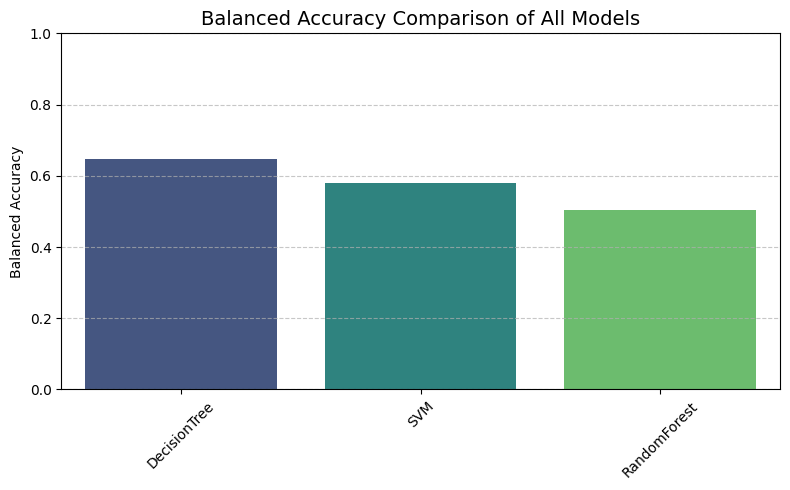

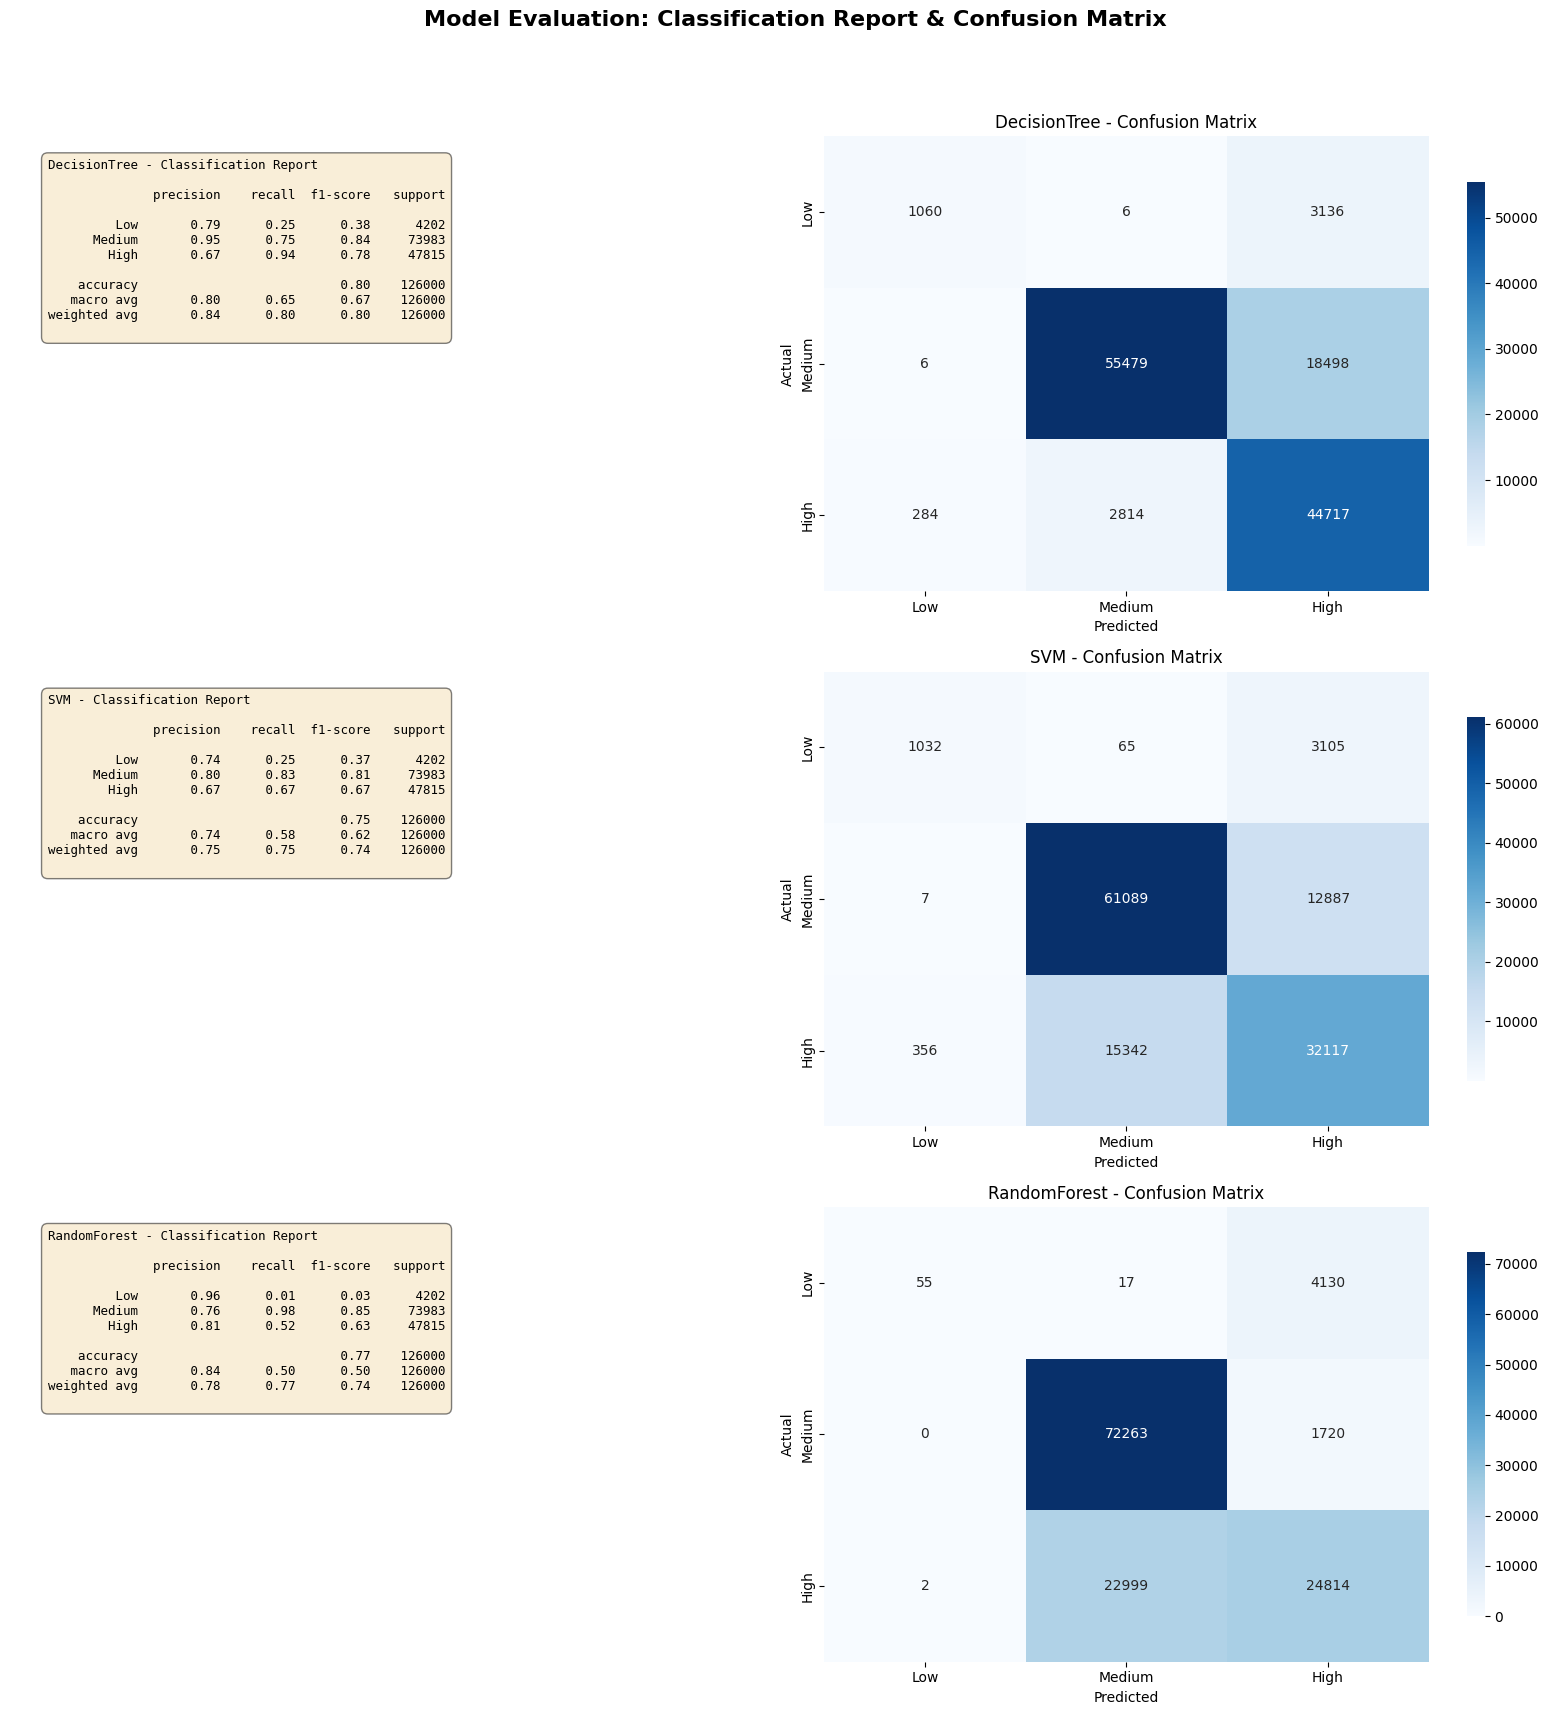

In [81]:
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

# --- 1. Visualisasi Balanced Accuracy semua model ---
model_names = list(models.keys())
scores = []
for name, mdl in models.items():
    mdl.fit(X_tr_10, y_tr_10)
    pred = mdl.predict(X_val)
    score = balanced_accuracy_score(y_val, pred)
    scores.append(score)

plt.figure(figsize=(8, 5))
sns.barplot(x=model_names, y=scores, palette='viridis')
plt.title('Balanced Accuracy Comparison of All Models', fontsize=14)
plt.ylabel('Balanced Accuracy')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- 2. Classification Report & Confusion Matrix untuk SEMUA MODEL ---
fig, axes = plt.subplots(3, 2, figsize=(16, 18))  # 3 baris (model), 2 kolom (report text + heatmap)
fig.suptitle('Model Evaluation: Classification Report & Confusion Matrix', fontsize=16, fontweight='bold')

# Siapkan daftar model untuk di-loop
model_list = [
    ('DecisionTree', DecisionTreeClassifier(max_depth=3, random_state=42)),
    ('SVM', SVC(kernel='linear', random_state=42)),
    ('RandomForest', RandomForestClassifier(n_estimators=5, max_depth=3, random_state=42))
]

# print("Unique labels in y_val:", sorted(y_val.unique()))
target_names = ['Low', 'Medium', 'High']  # GANTI JIKA PERLU!

for i, (name, mdl) in enumerate(model_list):
    # Fit dan predict
    mdl.fit(X_tr_10, y_tr_10)
    y_pred = mdl.predict(X_val)
    
    # --- Classification Report (sebagai teks di subplot kiri) ---
    report = classification_report(y_val, y_pred, target_names=target_names, output_dict=False)
    axes[i, 0].text(0.05, 0.95, f"{name} - Classification Report\n\n{report}", 
                    transform=axes[i, 0].transAxes, fontsize=9, verticalalignment='top',
                    family='monospace', bbox=dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.5))
    axes[i, 0].axis('off')  # hilangkan axis kosong
    
    # --- Confusion Matrix Heatmap (subplot kanan) ---
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i, 1],
                xticklabels=target_names, yticklabels=target_names,
                cbar_kws={'shrink': 0.8})
    axes[i, 1].set_title(f'{name} - Confusion Matrix', fontsize=12)
    axes[i, 1].set_ylabel('Actual')
    axes[i, 1].set_xlabel('Predicted')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # ruang untuk suptitle
plt.savefig('all_models_evaluation.png', dpi=150, bbox_inches='tight')  # opsional: simpan gambar
plt.show()

In [82]:
print("🔄 Sedang mempersiapkan submission...")

final_model = DecisionTreeClassifier(max_depth=3, random_state=42)
final_model.fit(X_proc, y)
predictions = final_model.predict(X_test_proc)

submission_df = pd.DataFrame({
    'id': test_df['id'],
    'Irrigation_Need': predictions
})

# Simpan ke CSV
submission_df.to_csv('submission.csv', index=False)

print("✅ submission.csv BERHASIL DIBUAT!")
print(f"   Total Baris: {len(submission_df)}")
print(f"   Distribusi Prediksi:\n{submission_df['Irrigation_Need'].value_counts()}")
print("\n📌 Silakan klik tombol 'Submit' di panel kanan Kaggle.")

🔄 Sedang mempersiapkan submission...
✅ submission.csv BERHASIL DIBUAT!
   Total Baris: 270000
   Distribusi Prediksi:
Irrigation_Need
Medium    142218
Low       124650
High        3132
Name: count, dtype: int64

📌 Silakan klik tombol 'Submit' di panel kanan Kaggle.
